
# 🧩 NMF Topic Modeling & Engagement Analysis

Discover interpretable tweet topics with **Non-negative Matrix Factorization (NMF)** and compare how each topic performs on **Likes** and **Retweets**.

**Pipeline overview:**
1. Load tweet data from SQLite
2. Clean and normalize tweet text
3. Build a TF-IDF matrix with unigrams and bigrams
4. Compare multiple NMF topic counts
5. Fit a final NMF model and assign a dominant topic to each tweet
6. Compare topic-level engagement and temporal patterns
7. Review representative tweets for interpretation

## 📂 1. Load Data

In [122]:
import sqlite3
import pandas as pd
from tabulate import tabulate

DB_PATH = "../data/tweetsCleanedDB.sqlite"
TABLE_NAME = "tweets"

conn = sqlite3.connect(DB_PATH)
print(f"Processing table: {TABLE_NAME}")

cols = pd.read_sql_query(f"PRAGMA table_info({TABLE_NAME});", conn)["name"].tolist()
df = pd.read_sql_query(f"SELECT * FROM {TABLE_NAME}", conn)
print(f"Loaded {len(df):,} rows")

if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df["date"] = df["timestamp"].dt.date
    df["time"] = df["timestamp"].dt.time
    df["day_name"] = df["timestamp"].dt.day_name()
    df["hour"] = df["timestamp"].dt.hour
    df["month"] = df["timestamp"].dt.month
    df["year"] = df["timestamp"].dt.year

print("" + "=" * 50)
print(f"Columns: {df.columns.tolist()}")
summary = pd.DataFrame([(TABLE_NAME, len(df))], columns=["table_name", "num_rows"])
print(tabulate(summary, headers="keys", tablefmt="github", showindex=False))

print("" + "=" * 50)
print("Column dtypes:")
dtype_df = pd.DataFrame({
    "column": df.dtypes.index,
    "pandas_dtype": df.dtypes.astype(str).values,
    "sqlite_type": pd.read_sql_query(f"PRAGMA table_info({TABLE_NAME});", conn)["type"].tolist() + ["derived"] * (len(df.columns) - len(cols))
})
print(tabulate(dtype_df, headers="keys", tablefmt="github", showindex=False))

Processing table: tweets
Loaded 9,976 rows
Columns: ['tweet_id', 'username', 'text', 'retweets', 'likes', 'timestamp', 'date', 'time', 'hour', 'day_name', 'year_week', 'year_month', 'year', 'month']
| table_name   |   num_rows |
|--------------|------------|
| tweets       |       9976 |
Column dtypes:
| column     | pandas_dtype   | sqlite_type   |
|------------|----------------|---------------|
| tweet_id   | object         | TEXT          |
| username   | object         | TEXT          |
| text       | object         | TEXT          |
| retweets   | int64          | INTEGER       |
| likes      | int64          | INTEGER       |
| timestamp  | datetime64[ns] | TIMESTAMP     |
| date       | object         | TEXT          |
| time       | object         | TEXT          |
| hour       | int32          | INTEGER       |
| day_name   | object         | TEXT          |
| year_week  | object         | TEXT          |
| year_month | object         | TEXT          |
| year       | int32    


## 🧪 2. Basic Data Quality Checks

This section keeps only the fields needed for topic modeling and engagement comparison.
The analysis is performed at the **tweet level**, because the dataset contains far more tweets than repeated users.


In [123]:
required_cols = ["tweet_id", "username", "text", "retweets", "likes", "timestamp"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

analysis_df = df[required_cols].copy()
analysis_df = analysis_df.dropna(subset=["text"])
analysis_df["text"] = analysis_df["text"].astype(str).str.strip()
analysis_df = analysis_df[analysis_df["text"] != ""].copy()

analysis_df["retweets"] = pd.to_numeric(analysis_df["retweets"], errors="coerce").fillna(0)
analysis_df["likes"] = pd.to_numeric(analysis_df["likes"], errors="coerce").fillna(0)
analysis_df["timestamp"] = pd.to_datetime(analysis_df["timestamp"], errors="coerce")
analysis_df["day_name"] = analysis_df["timestamp"].dt.day_name()
analysis_df["hour"] = analysis_df["timestamp"].dt.hour
analysis_df["month"] = analysis_df["timestamp"].dt.month

print(f"Rows used for analysis: {len(analysis_df):,}")
print(f"Unique usernames: {analysis_df['username'].nunique():,}")
print(f"Missing timestamps: {analysis_df['timestamp'].isna().sum():,}")

preview_cols = ["tweet_id", "username", "text", "retweets", "likes", "timestamp"]
print(tabulate(analysis_df[preview_cols].head(5), headers="keys", tablefmt="github", showindex=False))

Rows used for analysis: 9,976
Unique usernames: 9,425
Missing timestamps: 0
|   tweet_id | username       | text                                                                                                                                               |   retweets |   likes | timestamp           |
|------------|----------------|----------------------------------------------------------------------------------------------------------------------------------------------------|------------|---------|---------------------|
|          1 | julie81        | Party least receive say or single. Prevent prevent husband affect. May himself cup style evening protect. Effect another themselves stage perform. |          2 |      25 | 2023-01-30 11:00:51 |
|            |                | Possible try tax share style television with. Successful much sell development economy effect.                                                     |            |         |                     |
|          2 | richa


## 🧹 3. Text Cleaning

The goal is to preserve enough semantic signal for topic modeling while removing obvious noise.

**Cleaning steps:**
- Convert text to lowercase
- Remove URLs
- Remove `@mentions`
- Keep hashtag words but remove the `#` symbol
- Remove the leading `RT` token
- Remove punctuation and extra whitespace


In [124]:
import re
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)             # remove URLs
    text = re.sub(r"@\w+", " ", text)                       # remove mentions
    text = re.sub(r"#(\w+)", r"", text)                  # keep hashtag token, remove '#'
    text = re.sub(r"rt", " ", text)                    # remove retweet marker
    text = re.sub(r"[^a-z0-9\s]", " ", text)               # remove punctuation and symbols
    text = re.sub(r"\s+", " ", text).strip()               # normalize whitespace
    return text


analysis_df["text_clean"] = analysis_df["text"].map(clean_text)
analysis_df = analysis_df[analysis_df["text_clean"] != ""].copy()
analysis_df["text_len"] = analysis_df["text_clean"].str.len()
analysis_df["word_count"] = analysis_df["text_clean"].str.split().str.len()

print(tabulate(
    analysis_df[["text", "text_clean", "word_count"]].head(8),
    headers="keys",
    tablefmt="github",
    showindex=False,
    maxcolwidths=[60, 60, None],
))


| text                                                         | text_clean                                                   |   word_count |
|--------------------------------------------------------------|--------------------------------------------------------------|--------------|
| Party least receive say or single. Prevent prevent husband   | party least receive say or single prevent prevent husband    |           34 |
| affect. May himself cup style evening protect. Effect        | affect may himself cup style evening protect effect another  |              |
| another themselves stage perform.                            | themselves stage perform possible try tax share style        |              |
| Possible try tax share style television with. Successful     | television with successful much sell development economy     |              |
| much sell development economy effect.                        | effect                                                       |              |


## 🔡 4. TF-IDF Vectorization

NMF works well with a sparse non-negative document-term matrix.
Here we use **TF-IDF** with unigrams and bigrams so the model can capture both single tokens and short phrases.


In [125]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.90,
    max_features=5000,
)

X_tfidf = vectorizer.fit_transform(analysis_df["text_clean"])
feature_names = vectorizer.get_feature_names_out()

print(f"TF-IDF matrix shape: {X_tfidf.shape}")
print(f"Vocabulary size: {len(feature_names):,}")


TF-IDF matrix shape: (9976, 817)
Vocabulary size: 817



## 📏 5. Compare Candidate Topic Counts

There is no single perfect metric for NMF topic modeling.
This notebook compares a few candidate values of `k` using:

- **Reconstruction error**: lower is better
- **Topic diversity**: higher means the top words overlap less across topics

Use this section as a practical model selection guide, then set a final `chosen_k` below.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import NMF
import matplotlib.pyplot as plt

candidate_topics = [4, 6, 8, 10]
top_n_words = 10
selection_rows = []


def topic_diversity(model, vocab, top_n=10):
    top_terms = []
    for topic_weights in model.components_:
        top_idx = topic_weights.argsort()[::-1][:top_n]
        top_terms.extend(vocab[top_idx])
    return len(set(top_terms)) / max(len(top_terms), 1)


for k in candidate_topics:
    nmf_model = NMF(
        n_components=k,
        init="nndsvda",
        random_state=42,
        max_iter=400,
        alpha_W=0.0,
        alpha_H=0.0,
        l1_ratio=0.0,
    )
    W_k = nmf_model.fit_transform(X_tfidf)
    H_k = nmf_model.components_
    selection_rows.append({
        "k": k,
        "reconstruction_error": nmf_model.reconstruction_err_,
        "topic_diversity": topic_diversity(nmf_model, feature_names, top_n=top_n_words),
        "avg_topic_weight": W_k.max(axis=1).mean(),
    })

selection_df = pd.DataFrame(selection_rows)
print(tabulate(selection_df.round(4), headers="keys", tablefmt="github", showindex=False))

plt.figure(figsize=(8, 4))
plt.plot(selection_df["k"], selection_df["reconstruction_error"], marker="o")
plt.title("NMF Reconstruction Error by Topic Count")
plt.xlabel("Number of topics (k)")
plt.ylabel("Reconstruction error")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(selection_df["k"], selection_df["topic_diversity"], marker="o")
plt.title("Topic Diversity by Topic Count")
plt.xlabel("Number of topics (k)")
plt.ylabel("Topic diversity")
plt.grid(alpha=0.3)
plt.show()

/home/kunalpop/neo/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 400 reached. Increase it to improve convergence.
  warnings.warn(



### Comments

Pick the topic count that gives a **reasonable trade-off** between topic diversity and interpretability.
A larger `k` may reduce reconstruction error, but it can also create fragmented or repetitive topics.

**`k = 6`** is a good balance for a dataset of this size, the topic keywords remain distinct and meaningful.


## 🧠 6. Fit Final NMF Model

In [ ]:
chosen_k = 6

nmf = NMF(
    n_components=chosen_k,
    init="nndsvda",
    random_state=42,
    max_iter=400,
    alpha_W=0.0,
    alpha_H=0.0,
    l1_ratio=0.0,
)

W = nmf.fit_transform(X_tfidf)
H = nmf.components_

print(f"Final model fitted with k = {chosen_k}")
print(f"Reconstruction error: {nmf.reconstruction_err_:.4f}")


Final model fitted with k = 6
Reconstruction error: 97.7079


/home/kunalpop/neo/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 400 reached. Increase it to improve convergence.
  warnings.warn(



## 🏷️ 7. Inspect Topic Keywords

Each topic is represented by its top weighted terms in the TF-IDF space.
Use the output below to assign short manual labels for reporting.


In [ ]:
TOP_N = 12

def top_words_per_topic(model, vocab, top_n=10):
    rows = []
    for topic_id, topic_weights in enumerate(model.components_):
        top_idx = topic_weights.argsort()[::-1][:top_n]
        rows.append({
            "topic_id": topic_id,
            "top_terms": ", ".join(vocab[top_idx]),
        })
    return pd.DataFrame(rows)


topic_terms_df = top_words_per_topic(nmf, feature_names, top_n=TOP_N)
print(tabulate(topic_terms_df, headers="keys", tablefmt="github", showindex=False, maxcolwidths=[None, 120]))


|   topic_id | top_terms                                                                                                |
|------------|----------------------------------------------------------------------------------------------------------|
|          0 | look, worker, improve, reveal, job, debate, owner, friend, success, thank, treatment, word               |
|          1 | want, relationship, approach, huge, cultural, imagine, goal, turn, student, federal, financial, short    |
|          2 | room, test, parent, tv, meet, daughter, prove, voice, class, growth, consumer, agent                     |
|          3 | tax, forget, party, conference, try, seek, pass, table, situation, chance, answer, prevent               |
|          4 | business, east, born, believe, executive, case, professional, rise, quite, write, nice, term             |
|          5 | computer, operation, recent, resource, subject, light, current, cause, director, official, culture, hard |



## 📝 8. Add Manual Topic Labels

Replace the placeholder labels after reviewing the top terms.
This keeps the workflow transparent: the model discovers the word patterns, while the analyst adds the final human-readable label.


In [ ]:
# Update these labels after inspecting `topic_terms_df`.
topic_labels = {
    0: "Topic 0",
    1: "Topic 1",
    2: "Topic 2",
    3: "Topic 3",
    4: "Topic 4",
    5: "Topic 5",
}

analysis_df["dominant_topic"] = W.argmax(axis=1)
analysis_df["topic_weight"] = W.max(axis=1)
analysis_df["topic_label"] = analysis_df["dominant_topic"].map(topic_labels)

print(tabulate(
    analysis_df[["tweet_id", "text_clean", "dominant_topic", "topic_weight", "topic_label"]].head(10),
    headers="keys",
    tablefmt="github",
    showindex=False,
    maxcolwidths=[None, 90, None, None, None],
))


|   tweet_id | text_clean                                                                                 |   dominant_topic |   topic_weight | topic_label   |
|------------|--------------------------------------------------------------------------------------------|------------------|----------------|---------------|
|          1 | party least receive say or single prevent prevent husband affect may himself cup style     |                3 |      0.0598524 | Topic 3       |
|            | evening protect effect another themselves stage perform possible try tax share style       |                  |                |               |
|            | television with successful much sell development economy effect                            |                  |                |               |
|          2 | hotel still congress may member staff media draw buy fly identify on another turn minute   |                1 |      0.0395658 | Topic 1       |
|            | would local subject way b


## 📊 9. Topic-Level Engagement Comparison

This is the key business-facing output.
For each topic, compare:
- topic size
- average and median Likes
- average and median Retweets
- share of tweets in the top quartile of Likes / Retweets

Median values are included because averages can be distorted by a small number of unusually large engagement values.


In [ ]:
like_q75 = analysis_df["likes"].quantile(0.75)
retweet_q75 = analysis_df["retweets"].quantile(0.75)

analysis_df["high_like_flag"] = (analysis_df["likes"] >= like_q75).astype(int)
analysis_df["high_retweet_flag"] = (analysis_df["retweets"] >= retweet_q75).astype(int)

engagement_by_topic = (
    analysis_df.groupby(["dominant_topic", "topic_label"], as_index=False)
    .agg(
        tweet_count=("tweet_id", "count"),
        avg_likes=("likes", "mean"),
        median_likes=("likes", "median"),
        avg_retweets=("retweets", "mean"),
        median_retweets=("retweets", "median"),
        high_like_ratio=("high_like_flag", "mean"),
        high_retweet_ratio=("high_retweet_flag", "mean"),
        avg_topic_weight=("topic_weight", "mean"),
    )
    .sort_values(["avg_retweets", "avg_likes"], ascending=False)
)

engagement_by_topic[["avg_likes", "median_likes", "avg_retweets", "median_retweets", "high_like_ratio", "high_retweet_ratio", "avg_topic_weight"]] = (
    engagement_by_topic[["avg_likes", "median_likes", "avg_retweets", "median_retweets", "high_like_ratio", "high_retweet_ratio", "avg_topic_weight"]].round(3)
)

print(tabulate(engagement_by_topic, headers="keys", tablefmt="github", showindex=False))


|   dominant_topic | topic_label   |   tweet_count |   avg_likes |   median_likes |   avg_retweets |   median_retweets |   high_like_ratio |   high_retweet_ratio |   avg_topic_weight |
|------------------|---------------|---------------|-------------|----------------|----------------|-------------------|-------------------|----------------------|--------------------|
|                2 | Topic 2       |          1659 |      49.916 |             50 |         50.459 |                51 |             0.25  |                0.269 |              0.044 |
|                5 | Topic 5       |          1862 |      48.988 |             49 |         50.324 |                50 |             0.241 |                0.274 |              0.045 |
|                0 | Topic 0       |           998 |      49.519 |             49 |         49.837 |                49 |             0.242 |                0.245 |              0.04  |
|                3 | Topic 3       |          1692 |      49.912 |         

## 📈 10. Topic Size and Engagement Visualizations

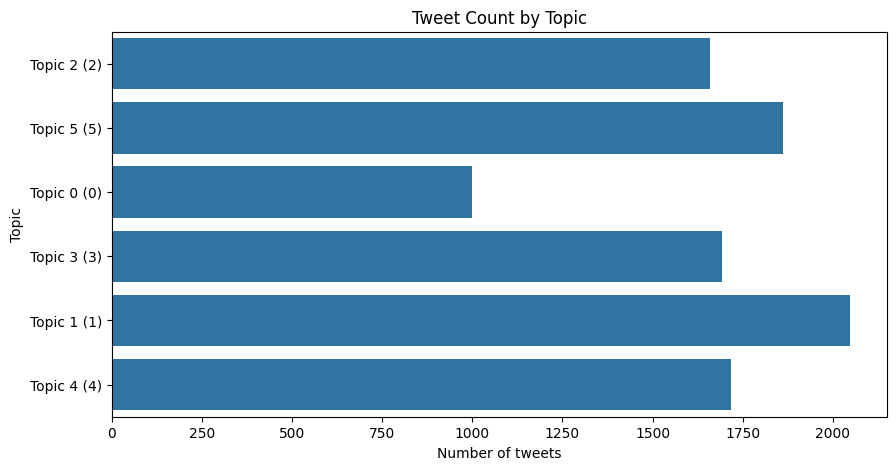

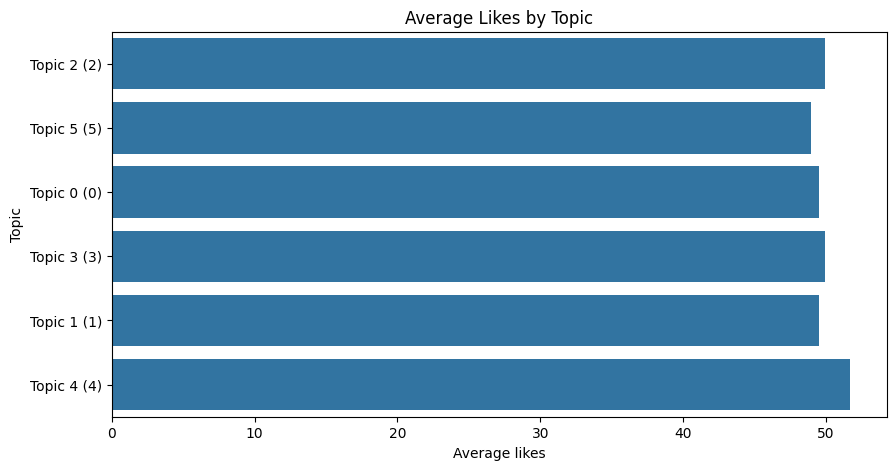

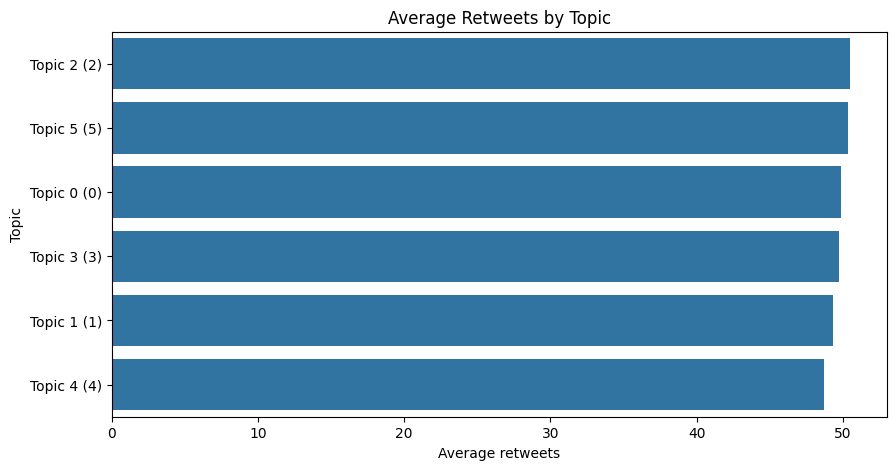

In [ ]:
import seaborn as sns

plot_df = engagement_by_topic.copy()
plot_df["topic_display"] = plot_df["topic_label"] + " (" + plot_df["dominant_topic"].astype(str) + ")"

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="tweet_count", y="topic_display")
plt.title("Tweet Count by Topic")
plt.xlabel("Number of tweets")
plt.ylabel("Topic")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="avg_likes", y="topic_display")
plt.title("Average Likes by Topic")
plt.xlabel("Average likes")
plt.ylabel("Topic")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="avg_retweets", y="topic_display")
plt.title("Average Retweets by Topic")
plt.xlabel("Average retweets")
plt.ylabel("Topic")
plt.show()



## 🗓️ 11. Temporal Pattern by Topic

This view checks whether some topics are posted more often at specific hours of the day.
It is useful for identifying whether topic differences may also be linked to posting time.


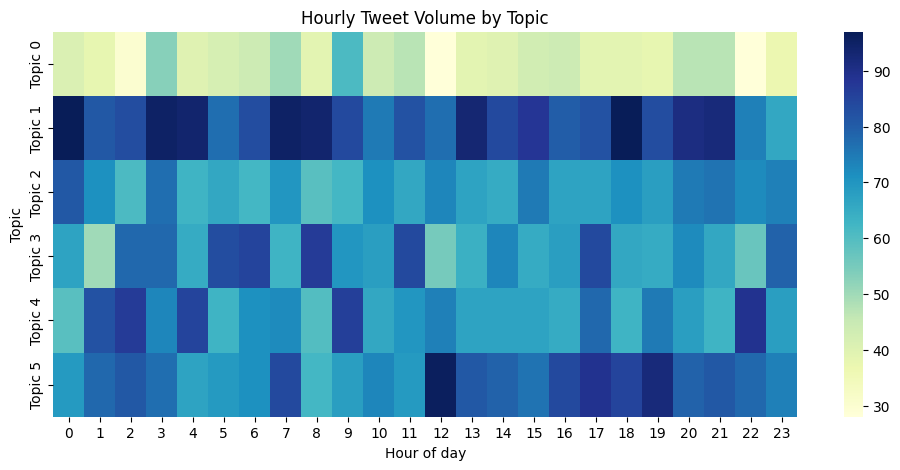

In [ ]:
valid_time_df = analysis_df.dropna(subset=["hour"]).copy()
hour_topic = (
    valid_time_df.groupby(["dominant_topic", "hour"])
    .size()
    .reset_index(name="tweet_count")
)

hour_pivot = hour_topic.pivot(index="dominant_topic", columns="hour", values="tweet_count").fillna(0)
hour_pivot.index = [topic_labels.get(i, f"Topic {i}") for i in hour_pivot.index]

plt.figure(figsize=(12, 5))
sns.heatmap(hour_pivot, cmap="YlGnBu")
plt.title("Hourly Tweet Volume by Topic")
plt.xlabel("Hour of day")
plt.ylabel("Topic")
plt.show()



## 🔍 12. Representative Tweets per Topic

Reviewing a few tweets from each topic is a simple but important validation step.
It helps verify whether the discovered topic words actually match the underlying text.


In [ ]:
SAMPLE_PER_TOPIC = 3

for topic_id in sorted(topic_labels):
    label = topic_labels.get(topic_id, f"Topic {topic_id}")
    topic_slice = (
        analysis_df[analysis_df["dominant_topic"] == topic_id]
        .sort_values(["topic_weight", "retweets", "likes"], ascending=False)
        [["tweet_id", "username", "retweets", "likes", "topic_weight", "text"]]
        .head(SAMPLE_PER_TOPIC)
    )

    print("" + "=" * 100)
    print(f"Topic {topic_id}: {label}")
    print(tabulate(topic_slice, headers="keys", tablefmt="github", showindex=False, maxcolwidths=[None, None, None, None, None, 120]))


Topic 0: Topic 0
|   tweet_id | username      |   retweets |   likes |   topic_weight | text                                                                                                                     |
|------------|---------------|------------|---------|----------------|--------------------------------------------------------------------------------------------------------------------------|
|       7251 | xjackson      |         56 |      33 |      0.0862381 | Here appear along affect watch. My if treatment or north adult sign. Figure world senior debate seat. Inside physical    |
|            |               |            |         |                | difference improve.                                                                                                      |
|            |               |            |         |                | Property attack improve much. Pm including their environment suffer help school. Look key sense hour.                    |
|       4257 


## 💾 13. Save Outputs

Save the tweet-level topic assignments and the topic summary table so they can be reused in later analysis or reporting.


In [ ]:
OUTPUT_TOPIC_ASSIGNMENTS = "../data/nmf_topic_assignments.csv"
OUTPUT_TOPIC_SUMMARY = "../data/nmf_topic_summary.csv"

analysis_df.to_csv(OUTPUT_TOPIC_ASSIGNMENTS, index=False)
engagement_by_topic.to_csv(OUTPUT_TOPIC_SUMMARY, index=False)

print(f"Saved tweet-level topic assignments to: {OUTPUT_TOPIC_ASSIGNMENTS}")
print(f"Saved topic-level summary to: {OUTPUT_TOPIC_SUMMARY}")


Saved tweet-level topic assignments to: ../data/nmf_topic_assignments.csv
Saved topic-level summary to: ../data/nmf_topic_summary.csv


## 14. Reload Saved Model Artifacts

This section demonstrates how to reload the saved topic modeling artifacts for reuse in a future session.

In [ ]:
# Save trained NMF pipeline artifacts for future reuse

import os
import json
import joblib
import numpy as np

MODEL_DIR = "../data/nmf_saved_model"
os.makedirs(MODEL_DIR, exist_ok=True)

# Save TF-IDF vectorizer
joblib.dump(vectorizer, os.path.join(MODEL_DIR, "tfidf_vectorizer.joblib"))

# Save trained NMF model
joblib.dump(nmf_model, os.path.join(MODEL_DIR, "nmf_model.joblib"))

# Save topic label mapping
with open(os.path.join(MODEL_DIR, "topic_labels.json"), "w", encoding="utf-8") as f:
    json.dump(topic_labels, f, ensure_ascii=False, indent=2)

# Save factorization matrices
np.save(os.path.join(MODEL_DIR, "W_document_topic.npy"), W)
np.save(os.path.join(MODEL_DIR, "H_topic_word.npy"), H)

# Save output tables again inside the model folder for convenience
engagement_by_topic.to_csv(os.path.join(MODEL_DIR, "topic_summary.csv"), index=False)
analysis_df.to_csv(os.path.join(MODEL_DIR, "topic_assignments.csv"), index=False)

print(f"All model artifacts saved to: {MODEL_DIR}")
print("Saved files:")
print("- tfidf_vectorizer.joblib")
print("- nmf_model.joblib")
print("- topic_labels.json")
print("- W_document_topic.npy")
print("- H_topic_word.npy")
print("- topic_summary.csv")
print("- topic_assignments.csv")

All model artifacts saved to: ../data/nmf_saved_model
Saved files:
- tfidf_vectorizer.joblib
- nmf_model.joblib
- topic_labels.json
- W_document_topic.npy
- H_topic_word.npy
- topic_summary.csv
- topic_assignments.csv


In [ ]:
analysis_df.head(5)

,tweet_id,username,text,retweets,likes,timestamp,day_name,hour,month,text_clean,text_len,word_count,dominant_topic,topic_weight,topic_label,high_like_flag,high_retweet_flag
0,1,julie81,Party least receive say or single. Prevent pre...,2,25,2023-01-30 11:00:51,Monday,11,1,party least receive say or single prevent prev...,235,34,3,0.059852,Topic 3,0,0
1,2,richardhester,Hotel still Congress may member staff. Media d...,35,29,2023-01-02 22:45:58,Monday,22,1,hotel still congress may member staff media dr...,185,30,1,0.039566,Topic 1,0,0
2,3,williamsjoseph,Nice be her debate industry that year. Film wh...,51,25,2023-01-18 11:25:19,Wednesday,11,1,nice be her debate industry that year film whe...,213,33,4,0.046067,Topic 4,0,0
3,4,danielsmary,Laugh explain situation career occur serious. ...,37,18,2023-04-10 22:06:29,Monday,22,4,laugh explain situation career occur serious f...,196,29,3,0.045041,Topic 3,0,0
4,5,carlwarren,Involve sense former often approach government...,27,80,2023-01-24 07:12:21,Tuesday,7,1,involve sense former often approach government...,266,39,1,0.044434,Topic 1,1,0


## 15. Assign Topics to New Texts

This section shows how to apply the saved TF-IDF vectorizer and NMF model to new tweet texts.

In [ ]:
import joblib
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.decomposition import NMF
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Define FULL pipelines (Text -> Topics -> Regression)
rt_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.90,
        max_features=5000
    )),
    ('nmf', NMF(
        n_components=10,
        random_state=42,
        init='nndsvd',
        max_iter=400
    )),
    ('regressor', LinearRegression())
])

lk_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.90,
        max_features=5000
    )),
    ('nmf', NMF(
        n_components=10,
        random_state=42,
        init='nndsvd',
        max_iter=400
    )),
    ('regressor', LinearRegression())
])

# 2. Prepare Data
X = analysis_df["text_clean"]
y_rt = analysis_df["retweets"]
y_lk = analysis_df["likes"]

# Split data
X_train, X_test, y_rt_train, y_rt_test, y_lk_train, y_lk_test = train_test_split(
    X, y_rt, y_lk, test_size=0.2, random_state=42
)

# 3. Train pipelines (no manual transform needed)
print("Training pipelines...")
rt_pipeline.fit(X_train, y_rt_train)
lk_pipeline.fit(X_train, y_lk_train)

# 4. Evaluation
def evaluate(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{label} - RMSE: {rmse:.2f}, R2: {r2:.4f}")

evaluate(y_rt_test, rt_pipeline.predict(X_test), "Retweets")
evaluate(y_lk_test, lk_pipeline.predict(X_test), "Likes")

# 5. Predict on Sample Tweets (directly on raw text)
sample_tweets = [
    "BREAKING: We just discovered a new Earth-like planet! #Space #Science",
    "I'm giving away 5 brand new iPhones! Retweet and follow to enter. #Giveaway",
    "The 10 habits of highly successful people. A thread 🧵",
    "Unbelievable comeback victory! History was made tonight. #Champions",
    "This is the most important video you will watch today. Change your life.",
    "I am currently eating a piece of dry toast. It is okay.",
    "Does anyone know if the mail has come yet?",
    "Just downloaded a new update for my calculator app.",
    "The weather today is exactly as predicted. Cloudy.",
    "Walking to the store to buy some milk. Back soon."
]

pred_rt = rt_pipeline.predict(sample_tweets)
pred_lk = lk_pipeline.predict(sample_tweets)

results = pd.DataFrame({
    "Tweet": sample_tweets,
    "Pred_Retweets": np.maximum(0, pred_rt).astype(int),
    "Pred_Likes": np.maximum(0, pred_lk).astype(int)
})

print("\n--- Sample Predictions ---")
print(results)

# 6. Save pipelines (each includes TF-IDF + NMF + model)
joblib.dump(rt_pipeline, "../models/retweet_pipeline.pkl")
joblib.dump(lk_pipeline, "../models/likes_pipeline.pkl")

Training pipelines...


/home/kunalpop/neo/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 400 reached. Increase it to improve convergence.
  warnings.warn(


Retweets - RMSE: 29.11, R2: -0.0019
Likes - RMSE: 28.85, R2: 0.0003

--- Sample Predictions ---
                                               Tweet  Pred_Retweets  \
0  BREAKING: We just discovered a new Earth-like ...             47   
1  I'm giving away 5 brand new iPhones! Retweet a...             47   
2  The 10 habits of highly successful people. A t...             46   
3  Unbelievable comeback victory! History was mad...             47   
4  This is the most important video you will watc...             47   
5  I am currently eating a piece of dry toast. It...             47   
6         Does anyone know if the mail has come yet?             46   
7  Just downloaded a new update for my calculator...             47   
8  The weather today is exactly as predicted. Clo...             47   
9  Walking to the store to buy some milk. Back soon.             47   

   Pred_Likes  
0          51  
1          50  
2          51  
3          51  
4          52  
5          52  
6         

/home/kunalpop/neo/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 400 reached. Increase it to improve convergence.
  warnings.warn(


['../models/likes_pipeline.pkl']